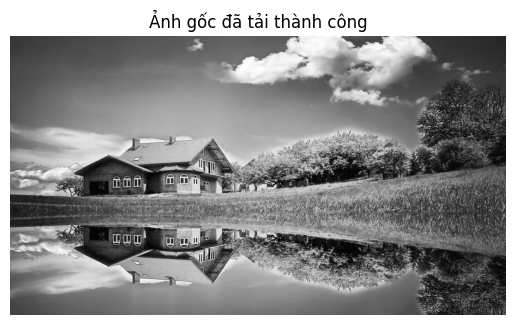

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_compare(original, processed, title_processed):
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Ảnh gốc")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap='gray')
    plt.title(title_processed)
    plt.axis('off')
    
    plt.show()

img = cv2.imread('lab02.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Lỗi: Không tìm thấy ảnh!")
else:
    plt.imshow(img, cmap='gray')
    plt.title("Ảnh gốc đã tải thành công")
    plt.axis('off')
    plt.show()

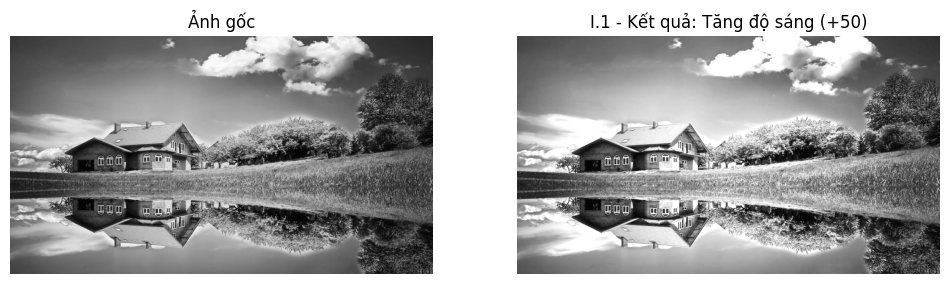

In [14]:
bright_img = cv2.convertScaleAbs(img, alpha=1, beta=50) 
show_compare(img, bright_img, "I.1 - Kết quả: Tăng độ sáng (+50)")

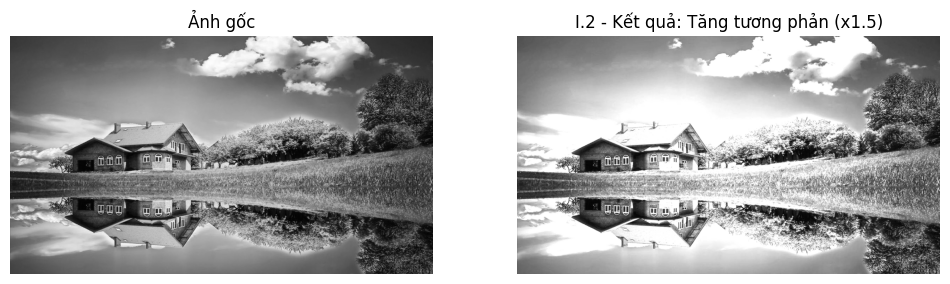

In [15]:
contrast_img = cv2.convertScaleAbs(img, alpha=1.5, beta=0) 
show_compare(img, contrast_img, "I.2 - Kết quả: Tăng tương phản (x1.5)")

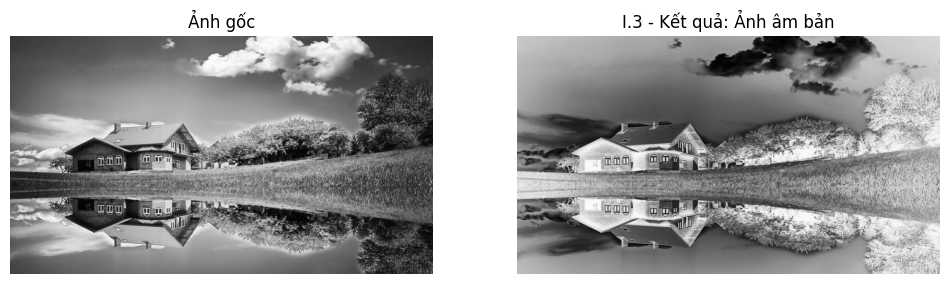

In [16]:
negative_img = 255 - img
show_compare(img, negative_img, "I.3 - Kết quả: Ảnh âm bản")

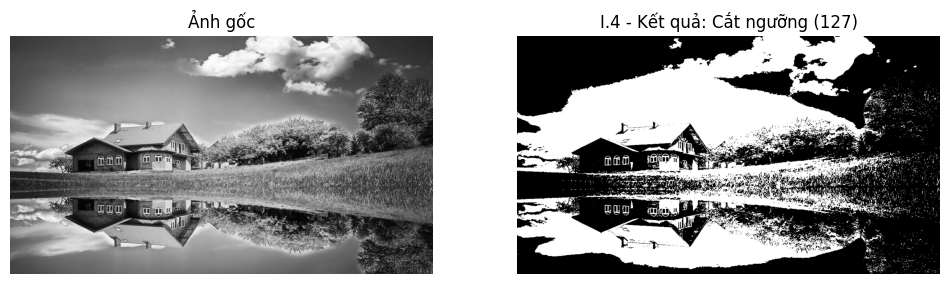

In [17]:
_, thresh_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
show_compare(img, thresh_img, "I.4 - Kết quả: Cắt ngưỡng (127)")

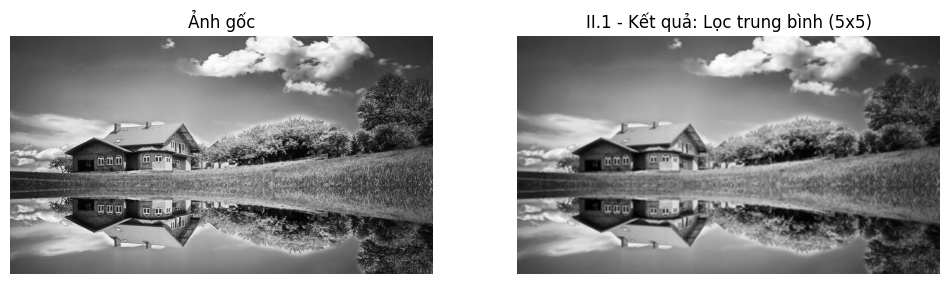

In [18]:
mean_blur = cv2.blur(img, (5, 5))
show_compare(img, mean_blur, "II.1 - Kết quả: Lọc trung bình (5x5)")

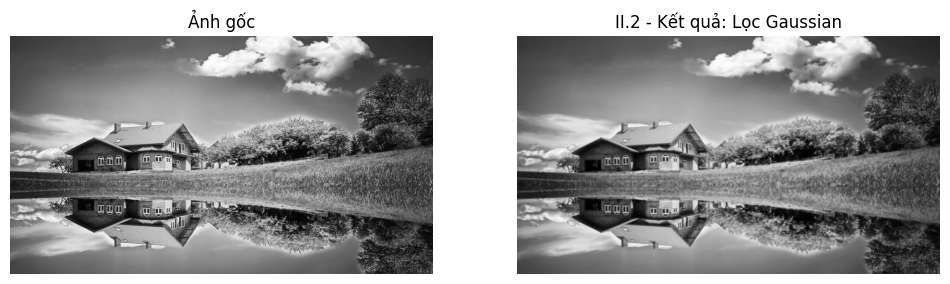

In [19]:
gaussian_blur = cv2.GaussianBlur(img, (5, 5), 0)
show_compare(img, gaussian_blur, "II.2 - Kết quả: Lọc Gaussian")

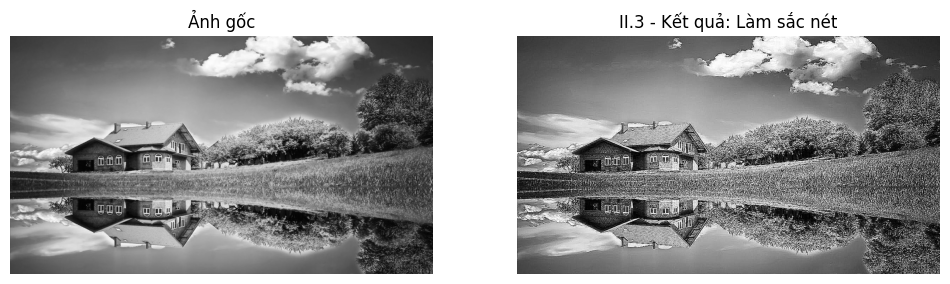

In [20]:
kernel_sharp = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
sharpened = cv2.filter2D(img, -1, kernel_sharp)
show_compare(img, sharpened, "II.3 - Kết quả: Làm sắc nét")

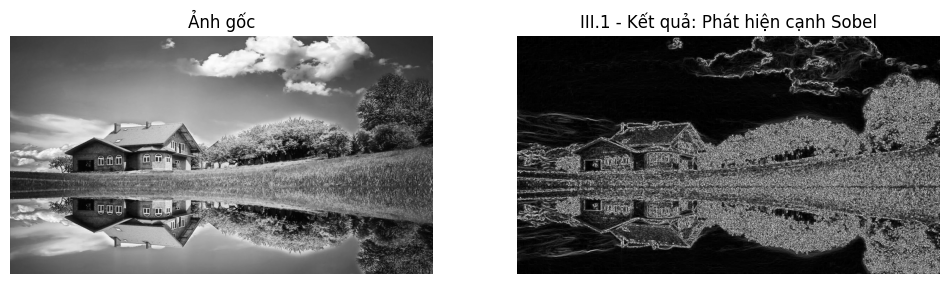

In [21]:
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely).astype(np.uint8)
show_compare(img, sobel_combined, "III.1 - Kết quả: Phát hiện cạnh Sobel")

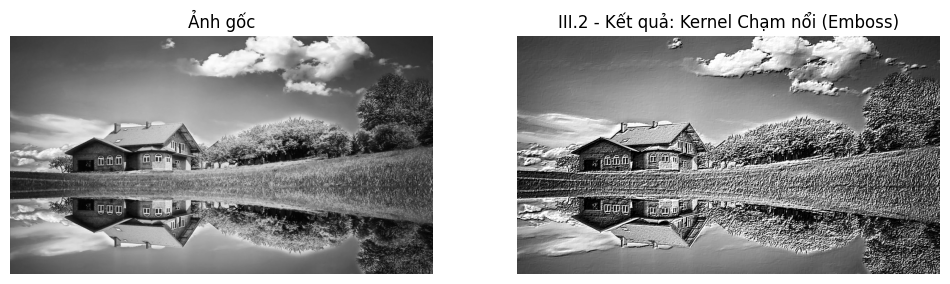

In [22]:
kernel_emboss = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])
embossed = cv2.filter2D(img, -1, kernel_emboss)
show_compare(img, embossed, "III.2 - Kết quả: Kernel Chạm nổi (Emboss)")

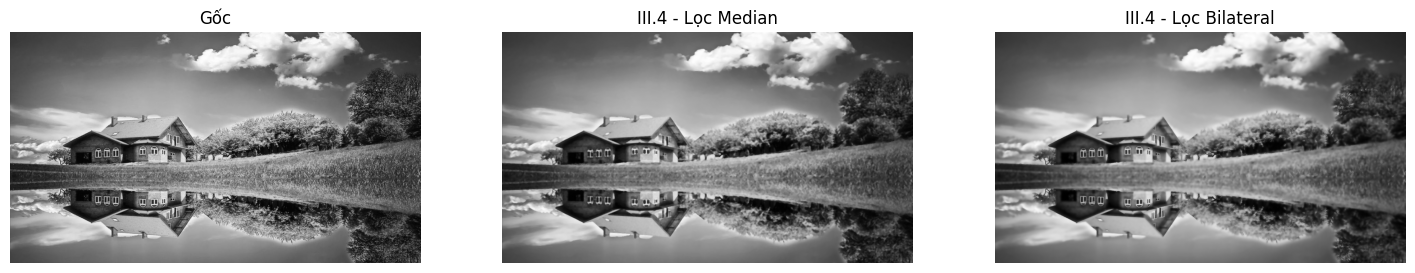

In [24]:
median = cv2.medianBlur(img, 5)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

# Hiển thị cả 3 ảnh để so sánh độ mịn
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title("Gốc"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(median, cmap='gray'); plt.title("III.4 - Lọc Median"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(bilateral, cmap='gray'); plt.title("III.4 - Lọc Bilateral"); plt.axis('off')
plt.show()